In [ ]:
# 1. download this file and .zip of cinic10 locally
# 2. put .zip on google drive in the main folder (MyDrive)
# 3. open google colab and just open this file, just select from local files, no connecting to github or whatever (you must be logged in the same google account as the drive)
# 4. when running the next cell give drive or google access to everything

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!unzip /content/drive/MyDrive/cinic10zip.zip -d /content/data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/drive/MyDrive/cinic10zip.zip
replace /content/data/README.md? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/data/imagenet-contributors.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [11]:
#downloading pretrained efficient net (non-pretrained version is available in torchvision.models)
#!pip install efficientnet_pytorch

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=b52b14e0d4a2e7c8cf246be4d437abc6ceecc667ae7add64bae3af27275d55ed
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet_pytorch


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import numpy as np
import random
import time
import os
import torchvision
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [2]:
# reproducibility

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    except Exception as e:
        pass


    print(f"full reproducibility with seed set at: {seed}")

!seed_everything(420)

/bin/bash: -c: line 1: syntax error near unexpected token `420'
/bin/bash: -c: line 1: `seed_everything(420)'


In [3]:
cinic_directory = './data/'
cinic_mean = [0.47889522, 0.47227842, 0.43047404]
cinic_std = [0.24205776, 0.23828046, 0.25874835]

transform_train = torchvision.transforms.Compose([
    torchvision.transforms.Resize(224),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(cinic_mean, cinic_std)
])

train_dataset = torchvision.datasets.ImageFolder(
    cinic_directory + '/test',
    transform=transform_train
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

transform_test = torchvision.transforms.Compose([
    torchvision.transforms.Resize(224),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(cinic_mean, cinic_std)
])

test_dataset = torchvision.datasets.ImageFolder(
    cinic_directory + '/test',
    transform=transform_test
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [4]:
images, labels = next(iter(train_loader))

print(f"shape of images batch: {images.shape}")
print(f"labels shape: {labels.shape}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


shape of images batch: torch.Size([128, 3, 224, 224])
labels shape: torch.Size([128])


image classes: ['ship', 'horse', 'cat', 'automobile', 'dog']


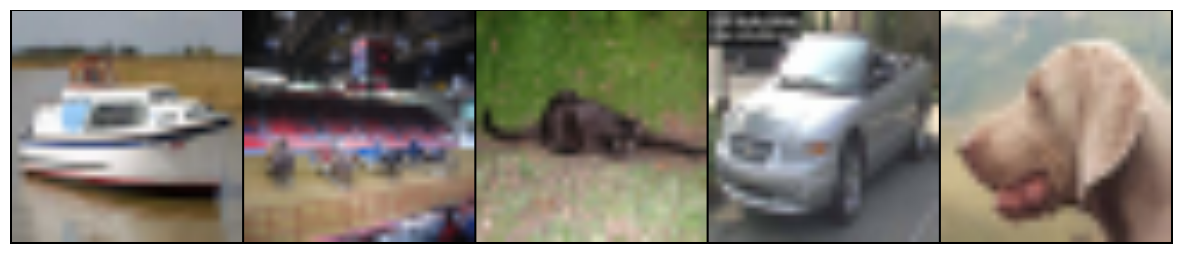

In [5]:
images, labels = next(iter(train_loader))

top_5_images = images[:5]

mean = torch.tensor(cinic_mean).view(3, 1, 1)
std = torch.tensor(cinic_std).view(3, 1, 1)
top_5_images = top_5_images * std + mean

grid = torchvision.utils.make_grid(top_5_images, nrow=5)

plt.figure(figsize=(15, 5))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis('off')

classes = train_loader.dataset.classes
titles = [classes[labels[i]] for i in range(5)]
print("image classes:", titles)

plt.show()

In [ ]:
# EFFICIENT NET - non-pretrained

In [6]:
from torchvision.models import efficientnet_b0

#checking memory state
print(torch.cuda.memory_allocated()/1024**3, "GB allocated")
print(torch.cuda.memory_reserved()/1024**3, "GB reserved")

#ensuring that computation is done on gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

#setting up the model
model =  efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 10) #setting the number of classes to 10 as it is in cinic10
model = model.to(device)

#cross-enthropy as our metric
criterion = nn.CrossEntropyLoss()

#we use ADAM optimizer in all experiments, for now lets set learning rate to 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

0.0 GB allocated
0.0 GB reserved
Device: cuda


In [7]:
#efficient net training loop

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for images, labels in progress_bar:
        #move data to gpu
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/10:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 1/10, Loss: 1.5429


Epoch 2/10:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 2/10, Loss: 1.1100


Epoch 3/10:   0%|          | 0/704 [00:00<?, ?it/s]

...

Epoch 8/10, Loss: 0.4902


Epoch 9/10:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 9/10, Loss: 0.4330


Epoch 10/10:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 10/10, Loss: 0.3850


In [8]:
#efficient net evalutation

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Test Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Test Accuracy: 90.20333333333333


In [10]:
#saving the model

torch.save(model.state_dict(), "/content/trained_models/efficientnet_non_pretrained_epochs_10.pth")

In [ ]:
# CNN